In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
data=pd.read_csv("train.csv")

print("Shape of dataset:", data.shape)
data.head()

Shape of dataset: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
if 'Id' in data.columns:
    data.drop('Id', axis=1, inplace=True)

num_cols=data.select_dtypes(include=['int64', 'float64']).columns
cat_cols=data.select_dtypes(include=['object']).columns

data[num_cols]=data[num_cols].fillna(data[num_cols].median())
data[cat_cols]=data[cat_cols].fillna(data[cat_cols].mode().iloc[0])

data=pd.get_dummies(data, drop_first=True)

data.shape

(1460, 245)

In [5]:
y=data['SalePrice']

X=data.drop('SalePrice', axis=1)

print("Total features after encoding", X.shape[1])

Total features after encoding 244


In [6]:
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [8]:
ridge=RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge.fit(X_train_scaled, y_train)

ridge_pred=ridge.predict(X_test_scaled)

ridge_r2=r2_score(y_test, ridge_pred)
ridge_rmse=np.sqrt(mean_squared_error(y_test, ridge_pred))

print("Best Alpha (Ridge):", ridge.alpha_)
print("R2 Score: (Ridge)", round(ridge_r2, 4))
print("RMSE (Ridge):", round(ridge_rmse, 2))

Best Alpha (Ridge): 429.1934260128778
R2 Score: (Ridge) 0.8592
RMSE (Ridge): 32862.6


In [9]:
lasso=LassoCV(cv=5, random_state=42, max_iter=5000)
lasso.fit(X_train_scaled, y_train)

lasso_pred=lasso.predict(X_test_scaled)

lasso_r2=r2_score(y_test, lasso_pred)
lasso_rmse=np.sqrt(mean_squared_error(y_test, lasso_pred))

print("Best Alpha (Lasso):", lasso.alpha_)
print("R2 Score: (Lasso)", round(lasso_r2, 4))
print("RMSE (Lasso):", round(lasso_rmse, 2))

Best Alpha (Lasso): 2626.2069809657028
R2 Score: (Lasso) 0.8461
RMSE (Lasso): 34362.87


In [10]:
lasso_coeff=pd.Series(lasso.coef_, index=X.columns)

important_features=lasso_coeff[lasso_coeff!=0].sort_values(key=abs, ascending=False)

print("Top 10 Important Features:")
important_features.head(10)

Top 10 Important Features:


GrLivArea               23130.384189
OverallQual             21799.802177
Neighborhood_NridgHt     7877.680564
GarageCars               7620.384070
MSSubClass              -6036.627960
Neighborhood_NoRidge     4368.412175
Neighborhood_StoneBr     3598.691195
BsmtFinSF1               3552.931043
YearRemodAdd             3498.127885
BsmtExposure_Gd          3134.234109
dtype: float64

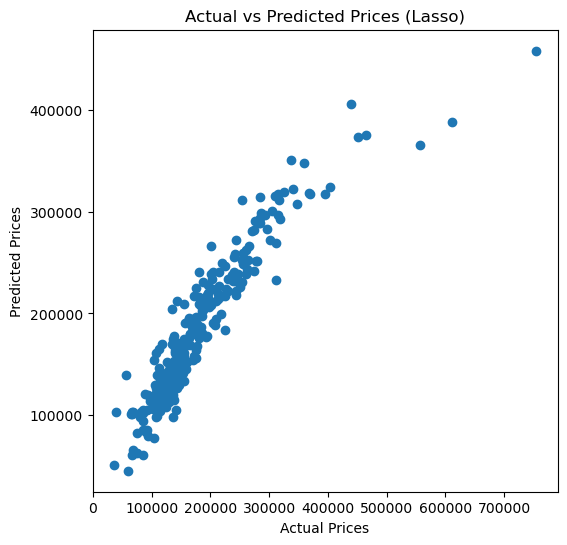

In [11]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, lasso_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (Lasso)")
plt.show()

In [12]:
ridge_cv=RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge_cv.fit(X_train_scaled, y_train)

lasso_cv=LassoCV(cv=5, max_iter=5000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

print("Optimal Alpha (Ridge):", ridge_cv.alpha_)
print("Optimal Alpha (Lasso):", lasso_cv.alpha_)

Optimal Alpha (Ridge): 429.1934260128778
Optimal Alpha (Lasso): 2626.2069809657028


In [13]:
ridge_pred=ridge_cv.predict(X_test_scaled)
lasso_pred=lasso_cv.predict(X_test_scaled)

print("Ridge R2:", r2_score(y_test, ridge_pred))
print("Lasso R2:", r2_score(y_test, lasso_pred))

print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))

Ridge R2: 0.8592040758696919
Lasso R2: 0.8460551738121347
Ridge RMSE: 32862.60285981364
Lasso RMSE: 34362.872912049286


In [17]:
from sklearn.linear_model import Ridge, Lasso

ridge_double=Ridge(alpha=2*ridge_cv.alpha_)
lasso_double=Lasso(alpha=2*lasso_cv.alpha_, max_iter=5000)

ridge_double.fit(X_train_scaled, y_train)
lasso_double.fit(X_train_scaled, y_train)

ridge_double_pred=ridge_double.predict(X_test_scaled)
lasso_double_pred=lasso_double.predict(X_test_scaled)

print("Ridge (Double Alpha) R2:", r2_score(y_test, ridge_double_pred))
print("Lasso (Double Alpha) R2:", r2_score(y_test, lasso_double_pred))

Ridge (Double Alpha) R2: 0.8440919345563936
Lasso (Double Alpha) R2: 0.8103489631529992


In [18]:
coeff_double=pd.Series(lasso_double.coef_, index=X.columns)

important_after_double=coeff_double[coeff_double!=0].sort_values(key=abs, ascending=False)

print("Top 10 Important Predictors (After Doubling Alpha):")
important_after_double.head(10)

Top 10 Important Predictors (After Doubling Alpha):


OverallQual             24850.606630
GrLivArea               20532.788336
GarageCars               8283.124019
Neighborhood_NridgHt     5212.672040
BsmtFinSF1               3917.071900
Neighborhood_NoRidge     2743.273306
YearRemodAdd             2715.064031
ExterQual_TA            -2565.670720
MSSubClass              -2557.016948
YearBuilt                2469.666500
dtype: float64

In [19]:
ridge_features=np.sum(ridge_cv.coef_!=0)
lasso_features=np.sum(lasso_cv.coef_!=0)

print("Ridge keeps features:", ridge_features)
print("Lasso keeps features:", lasso_features)

Ridge keeps features: 242
Lasso keeps features: 45


In [20]:
lasso_coeff=pd.Series(lasso_cv.coef_, index=X.columns)
top5=lasso_coeff[lasso_coeff!=0].sort_values(key=abs, ascending=False).head(5).index

print("Top 5 Removed Variables:")
print(top5)

Top 5 Removed Variables:
Index(['GrLivArea', 'OverallQual', 'Neighborhood_NridgHt', 'GarageCars',
       'MSSubClass'],
      dtype='object')


In [21]:
X_new=X.drop(columns=top5)

X_train_new, X_test_new, y_train_new, y_test_new=train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

X_train_new_scaled=scaler.fit_transform(X_train_new)
X_test_new_scaled=scaler.transform(X_test_new)

lasso_new=LassoCV(cv=5, max_iter=5000, random_state=42)
lasso_new.fit(X_train_new_scaled, y_train_new)

new_pred=lasso_new.predict(X_test_new_scaled)

print("New R2 (after removing top 5):", r2_score(y_test_new, new_pred))

New R2 (after removing top 5): 0.830309583872138


In [22]:
new_coeff=pd.Series(lasso_new.coef_, index=X_new.columns)

new_top5=new_coeff[new_coeff != 0].sort_values(key=abs, ascending=False).head(5)

print("New Top 5 Important Predictors:")
new_top5

New Top 5 Important Predictors:


1stFlrSF        13146.392258
2ndFlrSF        11245.726673
GarageArea       9973.582584
TotRmsAbvGrd     9481.213388
ExterQual_TA    -6671.653536
dtype: float64

In [23]:
from sklearn.model_selection import cross_val_score

cv_scores=cross_val_score(
    lasso_cv, X_train_scaled, y_train, cv=5, scoring='r2'
)

print("Cross Validation R2 Scores:", cv_scores)
print("Mean CV R2:", np.mean(cv_scores))

c:\Users\Suraj Shah\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 858248784.6386108, tolerance: 473794148.48336947
  model = cd_fast.enet_coordinate_descent_gram(


Cross Validation R2 Scores: [0.80865457 0.78135168 0.67942984 0.81990829 0.8251204 ]
Mean CV R2: 0.7828929562498004
